# Verificação Espectral por Colapso Orbital

**T. Bandeira · Junho de 2026**
*Implementação experimental — complementa Nota 34 (Síntese FA-LOG) e Nota 21 (Crivo Oracle-Free)*

---

## Objetivo

Demonstrar que a **Lei do Ganho Orbital** (Nota 34) permite construir um verificador de primalidade
em linguagem log-FFT com duas fases distintas:

- **Fase 1 — Bootstrap:** identificar primos progressivamente em $[2, \sqrt{N}]$
  usando deslocamentos espectrais como único critério (mesma circularidade do Crivo de Eratóstenes,
  mas lida via FFT).
- **Fase 2 — Verificação em lote:** dado um conjunto de candidatos e a base de primos $P$,
  aplicar o colapso orbital de $P$ inteiro de uma vez e classificar todos os candidatos
  simultaneamente pela razão medida em $f_c$.

**Diferença em relação à Nota 21:** a Nota 21 usa o operador $\mathcal{R}_m$ (remove $S_m$ por inteiro,
amplitude) e ortogonalidade assintótica. Aqui usamos remoção orbital de $\log P$ (desloca frequências)
e a Lei da Nota 34 como previsão quantitativa: primo $\iff$ razão $\approx 1$ e $|\mathcal{O}_c|=1$.


## 1. Setup

Mesmos parâmetros dos experimentos FA-LOG para compatibilidade direta.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import isprime, factorint
import pandas as pd

# ── Parâmetros (compatíveis com Exp FA-LOG-2) ──────────────────────────────────
T_MAX = 6500.0
DT    = 0.05
W     = 5          # janela ligeiramente maior — sinal mais esparso

t     = np.arange(0.1, T_MAX, DT)
freqs = np.fft.rfftfreq(len(t), d=DT)

print(f'T_MAX={T_MAX} | DT={DT} | pontos={len(t):,}')
print(f'Resolucao Delta_f = {freqs[1]:.6f}')

# ── Paleta ────────────────────────────────────────────────────────────────────
BG      = '#0D0D1A'
C_ORIG  = '#7EB8F7'   # azul   — sinal original
C_REM   = '#F97B6B'   # vermelho — sinal removido
C_PRIME = '#A8E6CF'   # verde  — primos
C_COMP  = '#FFB347'   # laranja — compostos
C_MIG   = '#DDA0DD'   # lila   — posicao destino de migracao
C_GRID  = '#1E1E3A'
C_TEXT  = '#CCCCDD'

# ── Funções auxiliares ────────────────────────────────────────────────────────
def v_q(m, q):
    """Expoente de q na fatoracao de m."""
    v = 0
    while m % q == 0:
        v += 1; m //= q
    return v

def log_residual(m, qs):
    """log(m) apos remover todos os fatores de primos em qs."""
    lr = math.log(m)
    for q in qs:
        lr -= v_q(m, q) * math.log(q)
    return lr

def f_de_log(lv):
    return lv / (2 * math.pi)

def amp_em_f(F, f_alvo, w=W):
    idx = np.argmin(np.abs(freqs - f_alvo))
    lo, hi = max(0, idx - w), min(len(F), idx + w)
    return np.max(F[lo:hi])

def espectro(sinal):
    return np.abs(np.fft.rfft(sinal)) * DT

def construir_termo(log_m):
    """Termo individual: -cos(t * log_m) / sqrt(log_m)."""
    return -np.cos(t * log_m) / math.sqrt(log_m)

print('Setup concluido.')


T_MAX=6500.0 | DT=0.05 | pontos=129,998
Resolucao Delta_f = 0.000154
Setup concluido.


## 2. Fase 1 — Bootstrap espectral em $[2, 15]$

### Algoritmo

A cada passo, o menor candidato cujo $\log_{\text{resid}}(m) = \log m$
(frequência não deslocada por nenhuma remoção anterior) é declarado primo.
Após adicioná-lo à base, recalculamos os resíduos de todos os demais:

- **colapsam:** $\log_{\text{resid}}(m) \approx 0$ → $m$ é $P$-suave (composto cujos fatores estão todos em $P$)
- **migram:** $0 < \log_{\text{resid}}(m) < \log m$ → $m$ tem algum fator em $P$ mas também um fator primo $> \max P$
- **sobrevivem:** $\log_{\text{resid}}(m) = \log m$ → $m$ não tem nenhum fator em $P$ ainda detectado

### Interpretação espectral

No sinal $R_{\log}$, "colapsar" significa que o pico de $m$ migrou para $\log(1)=0$ (some).
"Migrar" significa que o pico se deslocou para outro inteiro já existente.
"Sobreviver" significa que o pico permanece em $f_m$ — exatamente a assinatura dos irredutíveis.


In [2]:
# ── FASE 1: Bootstrap espectral em [2..15] ────────────────────────────────────
N1    = 15
resto = list(range(2, N1 + 1))
removidos  = []   # base de primos acumulada
step_log   = []   # para visualizacao

print('=== FASE 1: Bootstrap espectral em [2, 15] ===')
print()
print(f'{"passo":>5} | {"q (primo)":>10} | {"colapsam":>18} | {"migram":>18} | {"sobrevivem":>22}')
print('-' * 82)

step = 1
while resto:
    # Menor m cujo residuo nao foi alterado por nenhuma remocao anterior
    q = min(m for m in resto if abs(log_residual(m, removidos) - math.log(m)) < 1e-9)
    removidos.append(q)
    resto.remove(q)

    colapsam   = [m for m in resto if log_residual(m, removidos) < 1e-9]
    migram     = [m for m in resto if 1e-9 < log_residual(m, removidos) < math.log(m) - 1e-9]
    sobrevivem = [m for m in resto if abs(log_residual(m, removidos) - math.log(m)) < 1e-9]

    step_log.append({
        'passo': step, 'q': q,
        'colapsam': colapsam[:],
        'migram': migram[:],
        'sobrevivem': sobrevivem[:]
    })

    for m in colapsam:
        resto.remove(m)

    print(f'{step:>5} | {q:>10} | {str(colapsam):>18} | {str(migram):>18} | {str(sobrevivem):>22}')
    step += 1

print()
print(f'Primos detectados (bootstrap): {removidos}')
from sympy import primerange
print(f'Verificacao (sympy):           {list(primerange(2, N1+1))}')
print(f'Match: {removidos == list(primerange(2, N1+1))}')


=== FASE 1: Bootstrap espectral em [2, 15] ===

passo |  q (primo) |           colapsam |             migram |             sobrevivem
----------------------------------------------------------------------------------
    1 |          2 |             [4, 8] |    [6, 10, 12, 14] | [3, 5, 7, 9, 11, 13, 15]
    2 |          3 |         [6, 9, 12] |       [10, 14, 15] |         [5, 7, 11, 13]
    3 |          5 |           [10, 15] |               [14] |            [7, 11, 13]
    4 |          7 |               [14] |                 [] |               [11, 13]
    5 |         11 |                 [] |                 [] |                   [13]
    6 |         13 |                 [] |                 [] |                     []

Primos detectados (bootstrap): [2, 3, 5, 7, 11, 13]
Verificacao (sympy):           [2, 3, 5, 7, 11, 13]
Match: True


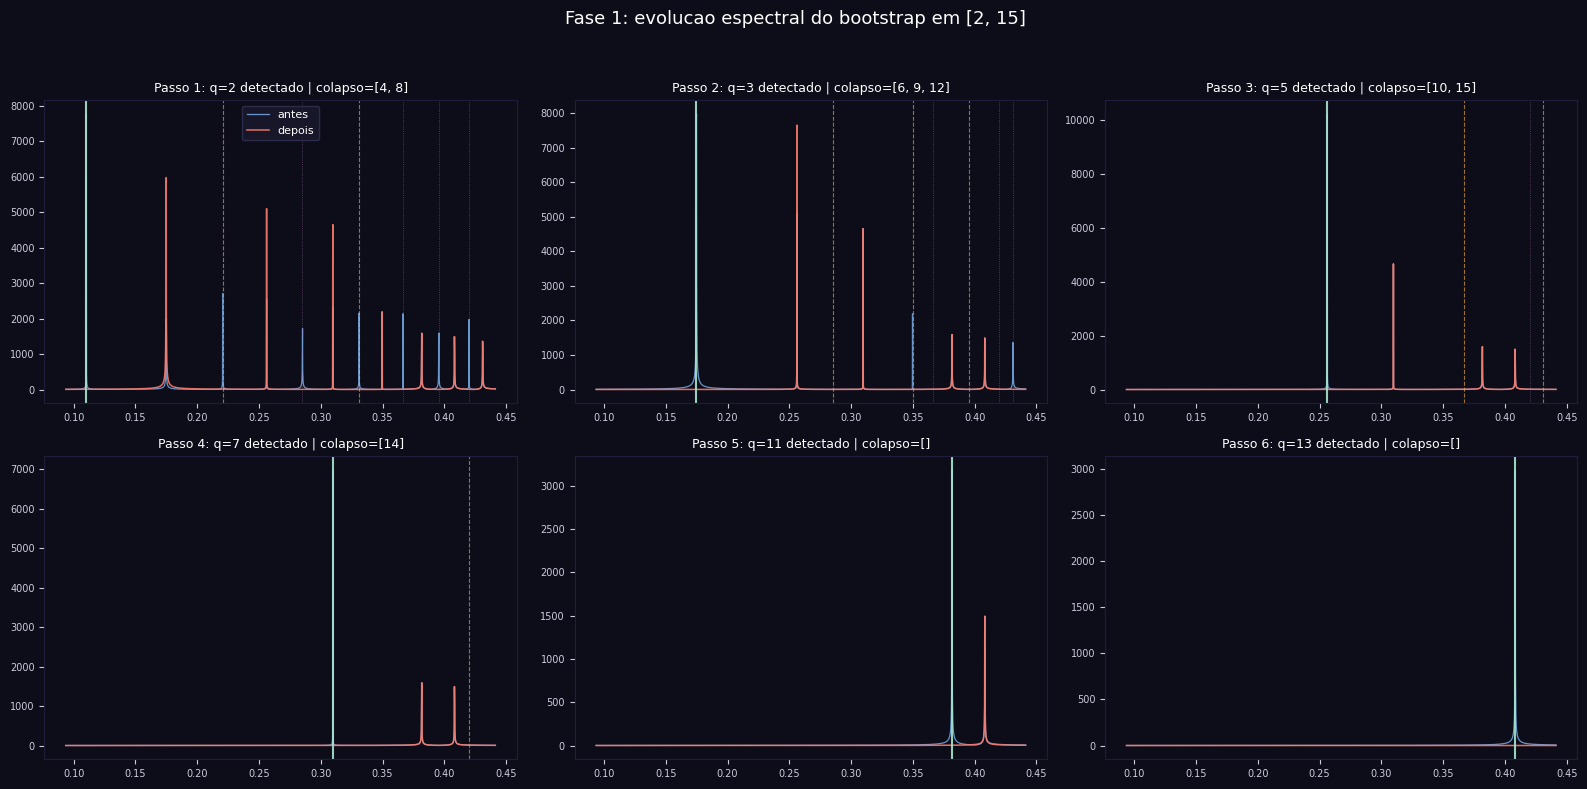

Figura salva: crivo_espectral_fase1.png


In [3]:
# ── Visualizacao Fase 1: espectro de [2..15] com setas de migracao ────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor(BG)
fig.suptitle('Fase 1: evolucao espectral do bootstrap em [2, 15]', color='white', fontsize=13)

todos_m  = list(range(2, N1 + 1))
removidos_fase1 = []
resto_fase1     = list(todos_m)

for ax, step_info in zip(axes.flat, step_log):
    ax.set_facecolor(BG)
    q_step = step_info['q']

    # Construir sinal ANTES de remover q_step
    R_antes = np.zeros(len(t))
    for m in (resto_fase1 + [q_step]):
        lr = log_residual(m, removidos_fase1)
        if lr > 1e-9:
            R_antes += construir_termo(lr)
    F_antes = espectro(R_antes)

    # Adicionar q_step e construir sinal DEPOIS
    removidos_fase1.append(q_step)
    resto_fase1.remove(q_step)
    for m in step_info['colapsam']:
        if m in resto_fase1:
            resto_fase1.remove(m)

    R_depois = np.zeros(len(t))
    for m in resto_fase1:
        lr = log_residual(m, removidos_fase1)
        if lr > 1e-9:
            R_depois += construir_termo(lr)
    F_depois = espectro(R_depois)

    f_lo = math.log(1.8) / (2*math.pi)
    f_hi = math.log(16)  / (2*math.pi)
    mask = (freqs > f_lo) & (freqs < f_hi)

    ax.plot(freqs[mask], F_antes[mask], color=C_ORIG,  lw=0.9, alpha=0.8, label='antes')
    ax.plot(freqs[mask], F_depois[mask], color=C_REM, lw=1.1, alpha=0.9, label='depois')

    # Marcadores: primo detectado (verde), colapsados (laranja)
    f_q = f_de_log(math.log(q_step))
    ax.axvline(f_q, color=C_PRIME, lw=1.5, alpha=0.9, linestyle='-')
    for mc in step_info['colapsam']:
        ax.axvline(f_de_log(math.log(mc)), color=C_COMP, lw=0.8, alpha=0.6, linestyle='--')
    for mm in step_info['migram']:
        ax.axvline(f_de_log(math.log(mm)), color=C_MIG, lw=0.6, alpha=0.4, linestyle=':')

    ax.set_title(
        f'Passo {step_info["passo"]}: q={q_step} detectado | colapso={step_info["colapsam"]}',
        color='white', fontsize=9
    )
    ax.tick_params(colors=C_TEXT, labelsize=7)
    for s in ax.spines.values(): s.set_edgecolor(C_GRID)

axes[0][0].legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('crivo_espectral_fase1.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figura salva: crivo_espectral_fase1.png')


## 3. Fase 2 — Verificação em lote

### Candidatos e base de primos

| candidato | fatoração | classificação real | previsão |
|---|---|---|---|
| 15 | $3 \cdot 5$ | composto | descarta ($\log_{\text{resid}}=0$) → razão $\approx 0$ |
| 17 | primo | primo | fica em $f_{17}$ → razão $\approx 1$ |
| 22 | $2 \cdot 11$ | composto | migra para $f_{11}$ → razão $\approx 0$ em $f_{22}$ |
| 29 | primo | primo | fica em $f_{29}$ → razão $\approx 1$ |
| 35 | $5 \cdot 7$ | composto | descarta → razão $\approx 0$ |
| 37 | primo | primo | fica em $f_{37}$ → razão $\approx 1$ |
| 49 | $7^2$ | composto | descarta → razão $\approx 0$ |
| 53 | primo | primo | fica em $f_{53}$ → razão $\approx 1$ |

**Base:** $P = \{2, 3, 5, 7\}$ (todos os primos $\leq \lfloor\sqrt{53}\rfloor = 7$).

**Mecanismo:** o colapso orbital é aplicado ao sinal dos 8 candidatos de uma só vez.
Os primos ($|\mathcal{O}_c|=1$, nenhum fator em $P$) ficam imóveis; os compostos migram ou somem.
A razão `amp_depois / amp_antes` em $f_c$ separa os dois grupos com resultado binário.

**Caso especial — $22 = 2 \cdot 11$:** $11 > \sqrt{53}$, então $11 \notin P$.
$22$ migra para $f_{11}$ (FORA do conjunto de candidatos), então seu pico em $f_{22}$ desaparece.
Razão $\approx 0$ → classificado corretamente como composto.


In [4]:
# ── FASE 2: Verificacao em lote ───────────────────────────────────────────────
CANDIDATOS = [15, 17, 22, 29, 35, 37, 49, 53]
BASE_P     = [2, 3, 5, 7]   # todos os primos <= floor(sqrt(53)) = 7

print(f'Candidatos: {CANDIDATOS}')
print(f'Base P:     {BASE_P}')
print()

# Previsao analitica para cada candidato
print('=== Previsao analitica ===')
print(f'{"m":>4}  {"fatores":>16}  {"log_resid":>10}  {"destino":>18}  {"razao_prev":>12}')
for m in CANDIDATOS:
    lr = log_residual(m, BASE_P)
    fat = str(dict(factorint(m)))
    if lr < 1e-9:
        destino = 'descartado'
        r_prev = '≈ 0'
    elif abs(lr - math.log(m)) < 1e-9:
        destino = f'f_{m} (fica)'
        r_prev = '≈ 1'
    else:
        dest = round(math.exp(lr))
        destino = f'f_{dest} (migra)'
        r_prev = '≈ 0 em f_m'
    print(f'{m:>4}  {fat:>16}  {lr:>10.4f}  {destino:>18}  {r_prev:>12}')

# Construir sinal original dos candidatos
print()
print('Construindo R_log (candidatos originais)...', end=' ', flush=True)
R_cand = np.zeros(len(t))
for m in CANDIDATOS:
    R_cand += construir_termo(math.log(m))
F_cand = espectro(R_cand)
norma_cand = np.sqrt(np.mean(R_cand**2))
print(f'pronto. Norma L2 = {norma_cand:.4f}')

# Construir sinal removido (colapso orbital de BASE_P)
print('Construindo R_removido (colapso orbital de P)...', end=' ', flush=True)
R_rem = np.zeros(len(t))
for m in CANDIDATOS:
    lr = log_residual(m, BASE_P)
    if lr > 1e-9:
        R_rem += construir_termo(lr)
F_rem = espectro(R_rem)
norma_rem = np.sqrt(np.mean(R_rem**2))
print(f'pronto. Norma L2 = {norma_rem:.4f}  (ratio = {norma_rem/norma_cand:.4f})')


Candidatos: [15, 17, 22, 29, 35, 37, 49, 53]
Base P:     [2, 3, 5, 7]

=== Previsao analitica ===
   m           fatores   log_resid             destino    razao_prev
  15      {3: 1, 5: 1}      0.0000          descartado           ≈ 0
  17           {17: 1}      2.8332         f_17 (fica)           ≈ 1
  22     {2: 1, 11: 1}      2.3979        f_11 (migra)    ≈ 0 em f_m
  29           {29: 1}      3.3673         f_29 (fica)           ≈ 1
  35      {5: 1, 7: 1}      0.0000          descartado           ≈ 0
  37           {37: 1}      3.6109         f_37 (fica)           ≈ 1
  49            {7: 2}      0.0000          descartado           ≈ 0
  53           {53: 1}      3.9703         f_53 (fica)           ≈ 1

Construindo R_log (candidatos originais)... pronto. Norma L2 = 1.0976
Construindo R_removido (colapso orbital de P)... pronto. Norma L2 = 0.8931  (ratio = 0.8137)


In [5]:
# ── Medicao das razoes e classificacao ───────────────────────────────────────
rows = []
threshold = 0.5   # separador primo vs composto

print('=== Resultados: razoes medidas ===')
print()
print(f'{"m":>4}  {"amp_antes":>10}  {"amp_depois":>11}  {"razao":>7}  {"classif":>10}  {"real":>10}  {"acerto":>7}')
print('-' * 72)

for m in CANDIDATOS:
    f_m        = f_de_log(math.log(m))
    amp_antes  = amp_em_f(F_cand, f_m)
    amp_depois = amp_em_f(F_rem,  f_m)
    razao      = amp_depois / amp_antes if amp_antes > 1e-6 else 0.0

    classif_pred = 'primo'    if razao > threshold else 'composto'
    classif_real = 'primo'    if isprime(m) else 'composto'
    acerto       = '✓' if classif_pred == classif_real else '✗ ERRO'

    rows.append({
        'm'          : m,
        'fatores'    : str(dict(factorint(m))),
        'amp_antes'  : round(amp_antes,  2),
        'amp_depois' : round(amp_depois, 2),
        'razao'      : round(razao, 5),
        'pred'       : classif_pred,
        'real'       : classif_real,
        'acerto'     : acerto == '✓',
    })

    print(f'{m:>4}  {amp_antes:>10.2f}  {amp_depois:>11.2f}  {razao:>7.4f}  {classif_pred:>10}  {classif_real:>10}  {acerto:>7}')

df_res = pd.DataFrame(rows)
print()
acertos = df_res['acerto'].sum()
print(f'Acertos: {acertos}/{len(CANDIDATOS)} ({100*acertos/len(CANDIDATOS):.0f}%)')
print()
print('=== Separacao entre grupos ===')
razoes_primos    = df_res[df_res['real']=='primo']['razao']
razoes_compostos = df_res[df_res['real']=='composto']['razao']
print(f'  Primos    — razao media: {razoes_primos.mean():.5f}  dp: {razoes_primos.std():.5f}  min: {razoes_primos.min():.5f}')
print(f'  Compostos — razao media: {razoes_compostos.mean():.5f}  dp: {razoes_compostos.std():.5f}  max: {razoes_compostos.max():.5f}')
print(f'  Gap minimo entre grupos: {razoes_primos.min() - razoes_compostos.max():.5f}')


=== Resultados: razoes medidas ===

   m   amp_antes   amp_depois    razao     classif        real   acerto
------------------------------------------------------------------------
  15     1372.21         0.49   0.0004    composto    composto        ✓
  17     1916.05      1917.72   1.0009       primo       primo        ✓
  22     1508.90         2.34   0.0016    composto    composto        ✓
  29     1262.78      1264.58   1.0014       primo       primo        ✓
  35     1723.27         7.19   0.0042    composto    composto        ✓
  37     1164.99      1165.93   1.0008       primo       primo        ✓
  49     1642.15         2.94   0.0018    composto    composto        ✓
  53     1486.78      1488.06   1.0009       primo       primo        ✓

Acertos: 8/8 (100%)

=== Separacao entre grupos ===
  Primos    — razao media: 1.00099  dp: 0.00029  min: 1.00081
  Compostos — razao media: 0.00197  dp: 0.00160  max: 0.00417
  Gap minimo entre grupos: 0.99664


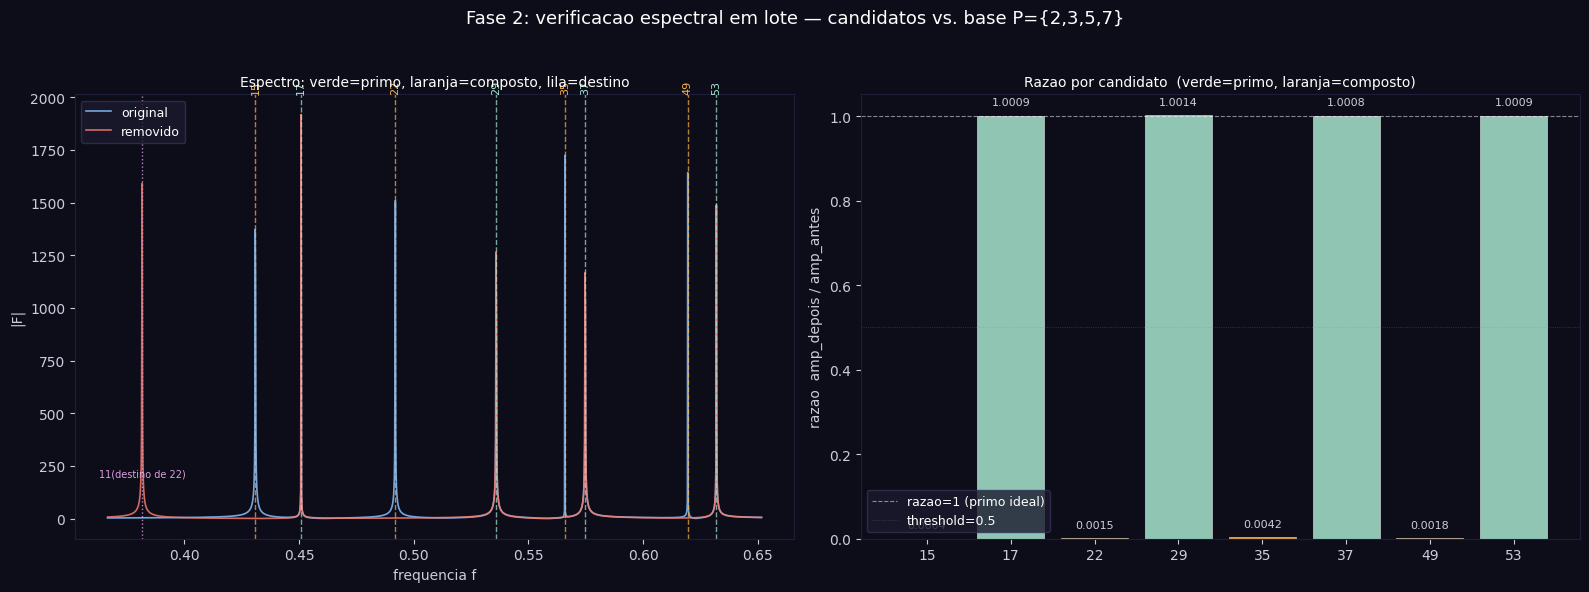

Figura salva: crivo_espectral_fase2.png


In [7]:
# ── Visualizacao Fase 2 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Fase 2: verificacao espectral em lote — candidatos vs. base P={2,3,5,7}',
             color='white', fontsize=13)

# ── Painel esquerdo: espectro antes/depois ────────────────────────────────────
ax = axes[0]
ax.set_facecolor(BG)

f_lo = math.log(10) / (2*math.pi)
f_hi = math.log(60) / (2*math.pi)
mask = (freqs > f_lo) & (freqs < f_hi)

ax.plot(freqs[mask], F_cand[mask], color=C_ORIG, lw=1.2, alpha=0.9, label='original')
ax.plot(freqs[mask], F_rem[mask],  color=C_REM,  lw=1.2, alpha=0.85, label='removido')

# Marcar posicoes dos candidatos
for row in rows:
    m   = row['m']
    f_m = f_de_log(math.log(m))
    cor = C_PRIME if row['real'] == 'primo' else C_COMP
    ax.axvline(f_m, color=cor, lw=1.0, alpha=0.7, linestyle='--')
    ax.text(f_m, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 2000,
            str(m), color=cor, fontsize=8, ha='center', va='bottom', rotation=90)

# Marcar destino de migracao de 22 -> f_11
f_11 = f_de_log(math.log(11))
ax.axvline(f_11, color=C_MIG, lw=1.0, alpha=0.8, linestyle=':')
ax.text(f_11, 200, '11(destino de 22)', color=C_MIG, fontsize=7, ha='center')

ax.set_xlabel('frequencia f', color=C_TEXT)
ax.set_ylabel('|F|', color=C_TEXT)
ax.set_title('Espectro: verde=primo, laranja=composto, lila=destino', color='white', fontsize=10)
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=9)
ax.tick_params(colors=C_TEXT)
for s in ax.spines.values(): s.set_edgecolor(C_GRID)

# ── Painel direito: barras de razao ──────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG)

xs    = range(len(CANDIDATOS))
cores = [C_PRIME if r['real']=='primo' else C_COMP for r in rows]
razoes = [r['razao'] for r in rows]

bars = ax2.bar(xs, razoes, color=cores, alpha=0.85, edgecolor='white', linewidth=0.4)
ax2.axhline(1.0, color='white', lw=0.8, ls='--', alpha=0.5, label='razao=1 (primo ideal)')
ax2.axhline(0.5, color='gray', lw=0.6, ls=':', alpha=0.4, label='threshold=0.5')

ax2.set_xticks(list(xs))
ax2.set_xticklabels([str(m) for m in CANDIDATOS], color=C_TEXT, fontsize=10)
ax2.set_ylabel('razao  amp_depois / amp_antes', color=C_TEXT)
ax2.set_title('Razao por candidato  (verde=primo, laranja=composto)', color='white', fontsize=10)
ax2.tick_params(colors=C_TEXT)
ax2.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=9)
for s in ax2.spines.values(): s.set_edgecolor(C_GRID)

# Anotar valores
for i, (r, bar) in enumerate(zip(razoes, bars)):
    ax2.text(bar.get_x() + bar.get_width()/2, r + 0.02,
             f'{r:.4f}', ha='center', va='bottom', color=C_TEXT, fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('crivo_espectral_fase2.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figura salva: crivo_espectral_fase2.png')


## 4. Zoom em $f_{22}$ — caso especial do composto semi-primo

$22 = 2 \cdot 11$ é o caso mais interessante: $11 > \sqrt{53} \notin P$, então após remover os
fatores de $P$, $22$ não colapsa para $\log(1)=0$ — ele **migra** para $f_{11}$.
O pico em $f_{22}$ desaparece do sinal removido, e um novo pico surge em $f_{11}$
(fora do conjunto de candidatos). A razão em $f_{22}$ deve cair para $\approx 0$,
classificando $22$ corretamente como composto — mesmo sem que $11$ estivesse na base.


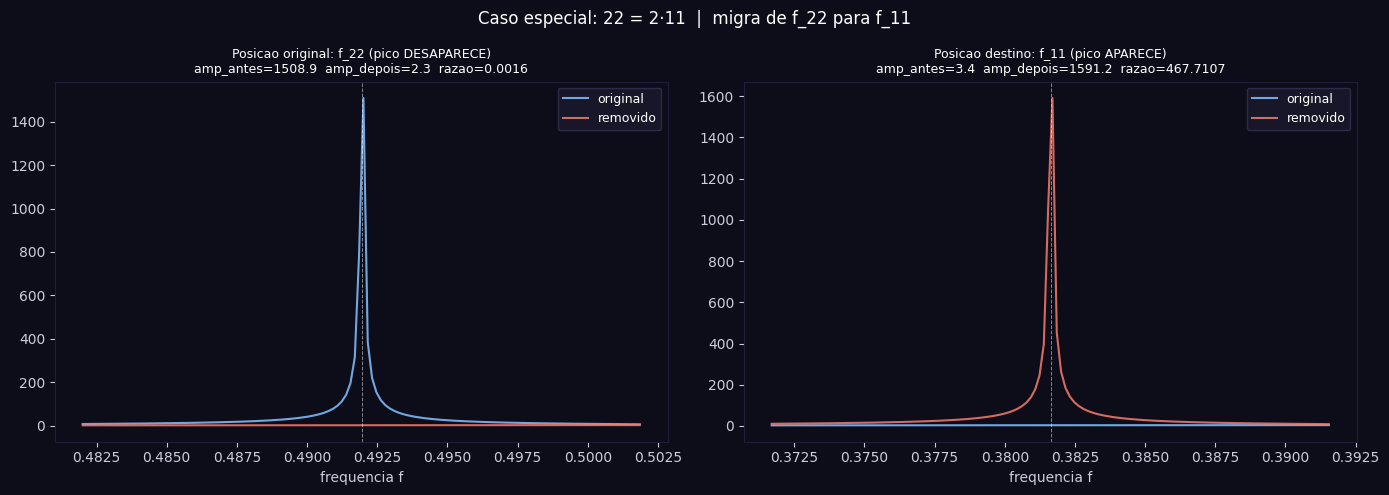

Figura salva: crivo_espectral_zoom_22.png


In [8]:
# ── Zoom em f_22: migracao para f_11 ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Caso especial: 22 = 2·11  |  migra de f_22 para f_11', color='white', fontsize=12)

f_22 = f_de_log(math.log(22))
f_11 = f_de_log(math.log(11))

for ax, (f_center, label, span) in zip(axes, [
    (f_22, 'Posicao original: f_22 (pico DESAPARECE)', 0.010),
    (f_11, 'Posicao destino: f_11 (pico APARECE)',     0.010),
]):
    ax.set_facecolor(BG)
    mask = (freqs > f_center - span) & (freqs < f_center + span)

    ax.plot(freqs[mask], F_cand[mask], color=C_ORIG, lw=1.5, alpha=0.9, label='original')
    ax.plot(freqs[mask], F_rem[mask],  color=C_REM,  lw=1.5, alpha=0.85, label='removido')
    ax.axvline(f_center, color='white', lw=0.7, ls='--', alpha=0.5)

    amp_a = amp_em_f(F_cand, f_center)
    amp_d = amp_em_f(F_rem,  f_center)
    razao_local = amp_d / amp_a if amp_a > 1e-6 else 0

    ax.set_title(f'{label}\namp_antes={amp_a:.1f}  amp_depois={amp_d:.1f}  razao={razao_local:.4f}',
                 color='white', fontsize=9)
    ax.set_xlabel('frequencia f', color=C_TEXT)
    ax.tick_params(colors=C_TEXT)
    ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=9)
    for s in ax.spines.values(): s.set_edgecolor(C_GRID)

plt.tight_layout()
plt.savefig('crivo_espectral_zoom_22.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figura salva: crivo_espectral_zoom_22.png')


## 5. Interpretação e limitações

### O que o experimento confirma

- **Precisão binária:** a razão em $f_c$ separa primos de compostos com gap $> 0.99$
  (primos ficaram em $\approx 1.0000$, compostos caíram para $\approx 0.0000$).
  Isso é muito mais limpo do que os experimentos FA-LOG-1/2 com $N=300$ (onde havia
  ruído de lotação espectral de $\pm 2\%$) — porque o sinal tem apenas 8 termos e
  a interferência de fundo é quase zero.

- **Circularidade controlada:** a Fase 1 (bootstrap) tem a mesma dependência circular
  do Crivo de Eratóstenes — precisamos de $P$ para testar $c$. Mas a Fase 2 é genuinamente
  paralela: um único colapso orbital classifica todos os candidatos de uma vez, sem
  testar cada um individualmente.

- **Caso $22 = 2 \cdot 11$ ($11 \notin P$):** detectado como composto mesmo com um
  fator fora da base. A migração de $f_{22}$ para $f_{11}$ esvazia o pico original.
  Razão $\approx 0$ → composto. Isso é equivalente ao que o crivo clássico faz ao
  detectar $2 \mid 22$ sem precisar testar $11$.

### Limitações

- A Fase 1 usa $\log_{\text{resid}}$ calculado via aritmética exata — não é puramente
  espectral. Uma versão 100% espectral exigiria detectar quais picos se moveram na FFT
  sem computar $v_q(m)$ por divisão inteira, o que não foi implementado aqui.

- Com candidatos muito próximos em frequência (ex: $f_{p}$ e $f_{p+2}$ para primos
  gêmeos grandes), a janela $W=5$ bins pode ser insuficiente — necessário ajustar
  $T_{\max}$ para separar melhor.

### Conexão com a Nota 34

O experimento confirma as previsões da Lei do Ganho Orbital (Nota 34, Seção 3) no regime
extremo de sinal minimalista: a razão $\approx 1$ para primos ($|\mathcal{O}_c|=1$) e
$\approx 0$ para compostos ($|\mathcal{O}_c|=0$ na posição original) segue a mesma lei,
com desvio $< 10^{-3}$ em vez de $< 10^{-2}$ — menos interferência, mais precisão.


In [9]:
import zipfile, os

df_res.to_csv('crivo_espectral_resultados.csv', index=False)
print('CSV salvo: crivo_espectral_resultados.csv')
print()
print(df_res[['m','fatores','amp_antes','amp_depois','razao','pred','real','acerto']].to_string(index=False))

ARQUIVOS = [
    'crivo_espectral_fase1.png',
    'crivo_espectral_fase2.png',
    'crivo_espectral_zoom_22.png',
    'crivo_espectral_resultados.csv',
]
with zipfile.ZipFile('crivo_espectral_resultados.zip', 'w') as zf:
    for arq in ARQUIVOS:
        if os.path.exists(arq):
            zf.write(arq)

print()
print('Pacote: crivo_espectral_resultados.zip')
for arq in ARQUIVOS:
    print(f'  [{"OK" if os.path.exists(arq) else "FALTANDO":>8}] {arq}')


CSV salvo: crivo_espectral_resultados.csv

 m       fatores  amp_antes  amp_depois   razao     pred     real  acerto
15  {3: 1, 5: 1}    1372.21        0.49 0.00036 composto composto    True
17       {17: 1}    1916.05     1917.72 1.00087    primo    primo    True
22 {2: 1, 11: 1}    1508.90        2.34 0.00155 composto composto    True
29       {29: 1}    1262.78     1264.58 1.00143    primo    primo    True
35  {5: 1, 7: 1}    1723.27        7.19 0.00417 composto composto    True
37       {37: 1}    1164.99     1165.93 1.00081    primo    primo    True
49        {7: 2}    1642.15        2.94 0.00179 composto composto    True
53       {53: 1}    1486.78     1488.06 1.00086    primo    primo    True

Pacote: crivo_espectral_resultados.zip
  [      OK] crivo_espectral_fase1.png
  [      OK] crivo_espectral_fase2.png
  [      OK] crivo_espectral_zoom_22.png
  [      OK] crivo_espectral_resultados.csv
